# Exercise
WE want only data analysit job, ploted the number of skills wanted against the month

In [40]:
# Import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [41]:
df_DA = df[df['job_title_short'] == 'Data Analyst']

Months

In [42]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA.sample(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
596627,Data Analyst,Data Analyst,Dubai - United Arab Emirates,via Indeed,Full-time,False,United Arab Emirates,2023-01-23 09:51:57,True,False,United Arab Emirates,NaN,NaN,NaN,UAEJOBS,[excel],{'analyst_tools': ['excel']},1
155137,Data Analyst,Insights and Analytics Officer,"Makati, Metro Manila, Philippines",via LinkedIn,NaN,False,Philippines,2023-12-15 08:08:56,False,False,Philippines,NaN,NaN,NaN,The Remote Group,"[sql, python, r, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",12
366775,Data Analyst,L 13 data analyst,"Santiago, Chile",via Sercanto,Full-time,False,Chile,2023-04-08 23:40:59,True,False,Chile,NaN,NaN,NaN,Falabella Equipo Corporativo,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",4
486212,Data Analyst,Lead Master Data Analyst,"Atlanta, GA",via Indeed,Full-time,False,Georgia,2023-06-15 14:43:32,False,True,United States,year,95274.96875,NaN,Eaton Corporation,"[sap, power bi, excel, word, powerpoint, share...","{'analyst_tools': ['sap', 'power bi', 'excel',...",6
59203,Data Analyst,"data analyst (healthcare, sql, tableau)","Basking Ridge, NJ",via Adzuna,Full-time,False,"New York, United States",2023-02-04 06:00:04,True,True,United States,NaN,NaN,NaN,Randstad US,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ...",2


Explode

In [43]:
df_DA_explode = df_DA.explode('job_skills')
df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)



job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [44]:
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['total'] = df_DA_pivot.sum()
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [45]:
df_DA_pivot.loc['total'].sort_values(ascending =False)

job_skills
sql          92428
excel        66860
python       57190
tableau      46455
power bi     39380
             ...  
esquisse         1
suse             1
capacitor        1
chainer          1
msaccess         1
Name: total, Length: 235, dtype: int64

In [46]:
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending =False).index]
df_DA_pivot = df_DA_pivot.drop('total')


In [47]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,angular.js,xamarin,gtx,nuxt.js,ovh,esquisse,suse,capacitor,chainer,msaccess
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,2,0,0,1,0,0,0,1,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,0,1,0,0,0,0,1,0,0,0
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,1,0,0,0,0,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,0,0,1
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

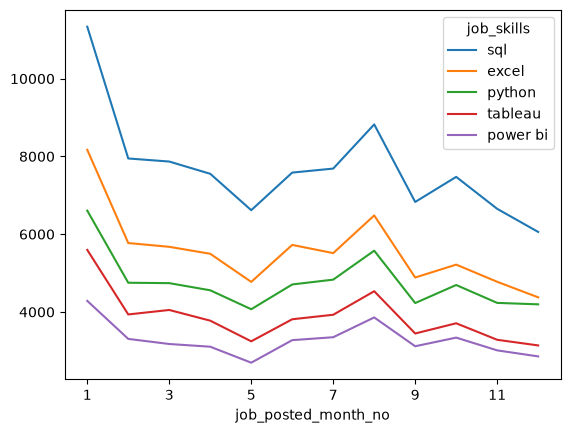

In [48]:
df_DA_pivot.iloc[:,:5].plot(kind='line')